In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
df = pd.read_csv("billing_data_10_lakh.csv")

In [69]:
df.shape

(1000000, 4)

In [70]:
df.columns

Index(['SKU', 'Billing_Date', 'Billing_Quantity', 'Customer_ID'], dtype='str')

In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 4 columns):
 #   Column            Non-Null Count    Dtype
---  ------            --------------    -----
 0   SKU               1000000 non-null  str  
 1   Billing_Date      1000000 non-null  str  
 2   Billing_Quantity  1000000 non-null  int64
 3   Customer_ID       1000000 non-null  str  
dtypes: int64(1), str(3)
memory usage: 30.5 MB


In [72]:
df.describe()

,Billing_Quantity
count,1000000.000000
mean,25.270830
std,17.011936
min,1.000000
25%,13.000000
50%,22.000000
75%,33.000000
max,100.000000


In [73]:
df.isnull().sum()

SKU                 0
Billing_Date        0
Billing_Quantity    0
Customer_ID         0
dtype: int64

In [74]:
df["Customer_ID"].nunique()

15000

In [75]:
df["SKU"].nunique()

11168

In [76]:
df["Billing_Date"] = pd.to_datetime(df["Billing_Date"])

In [77]:
#Creating new Time Columns
df["Year"] = df["Billing_Date"].dt.year
df["Month"] = df["Billing_Date"].dt.month

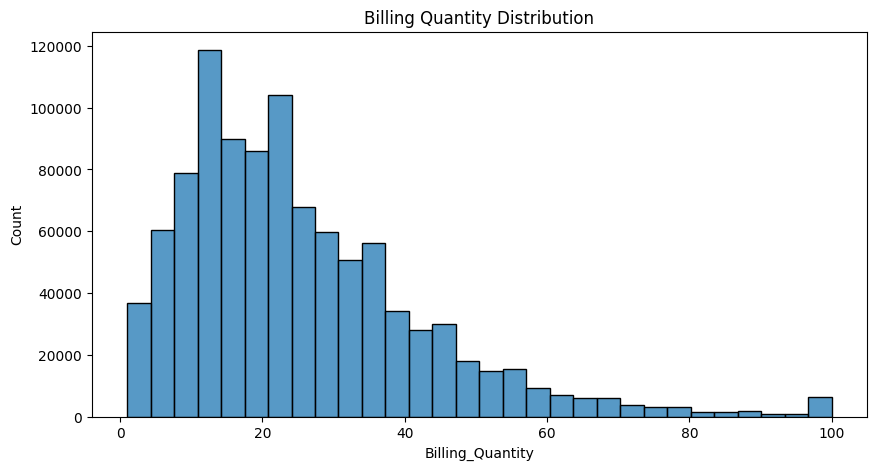

In [78]:
#Quantity Distribution
plt.figure(figsize=(10,5))
sns.histplot(df["Billing_Quantity"], bins=30)
plt.title("Billing Quantity Distribution")
plt.show()

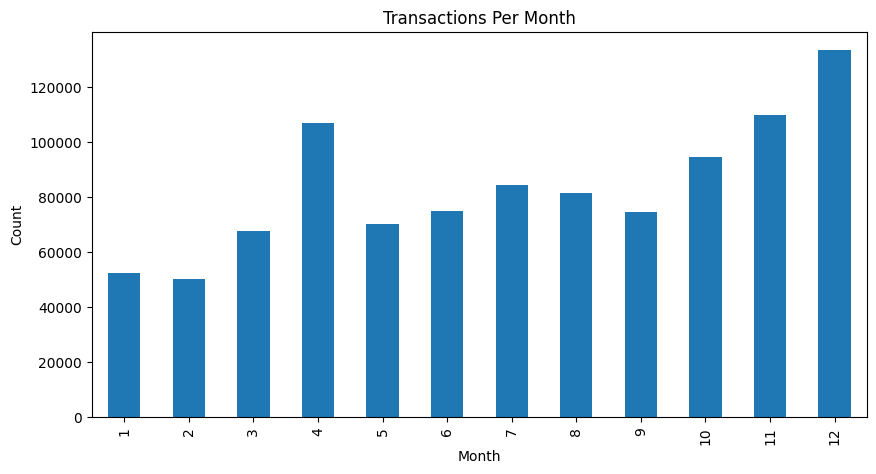

In [79]:
#Transactions Per Month
monthly_sales = df.groupby("Month").size()

monthly_sales.plot(kind="bar", figsize=(10,5))
plt.title("Transactions Per Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()

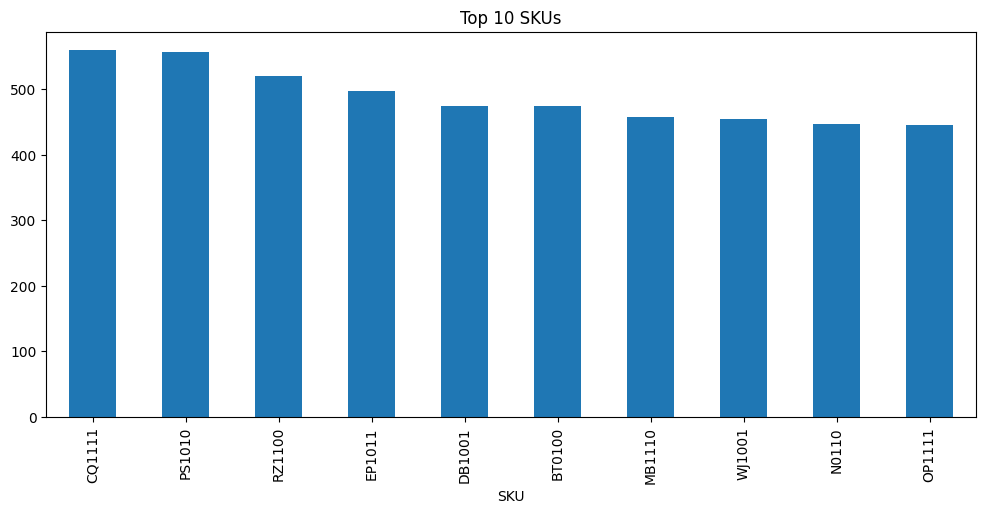

In [80]:
#Top 10 Most Sold SKUs
top_skus = df["SKU"].value_counts().head(10)

top_skus.plot(kind="bar", figsize=(12,5))
plt.title("Top 10 SKUs")
plt.show()

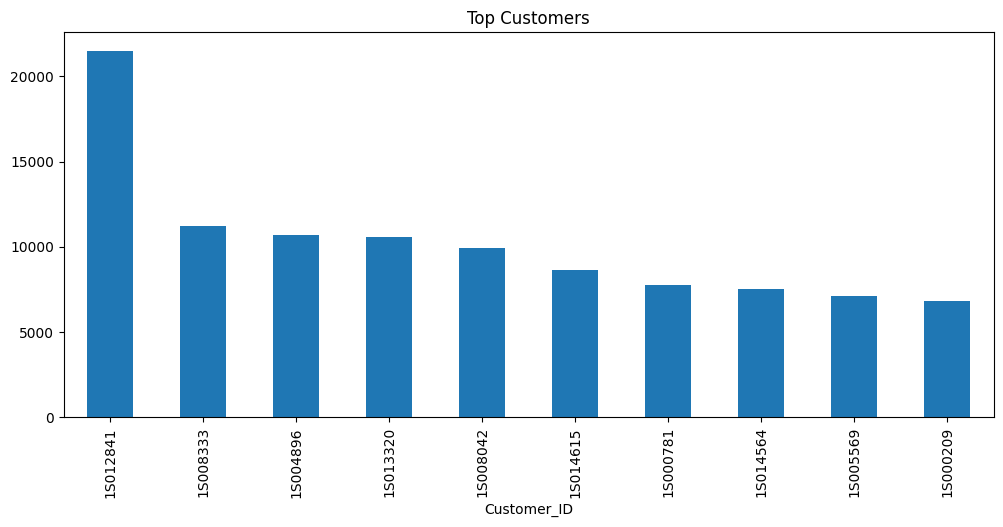

In [81]:
#Top Customers
top_customers = df["Customer_ID"].value_counts().head(10)

top_customers.plot(kind="bar", figsize=(12,5))
plt.title("Top Customers")
plt.show()

In [82]:
#Creating synthetic revenue and a column for it
df["Price"] = np.random.randint(100, 5000, size=len(df))

df["Revenue"] = df["Price"] * df["Billing_Quantity"]

In [83]:
#Total Revenue
df["Revenue"].sum()


np.int64(64431949260)

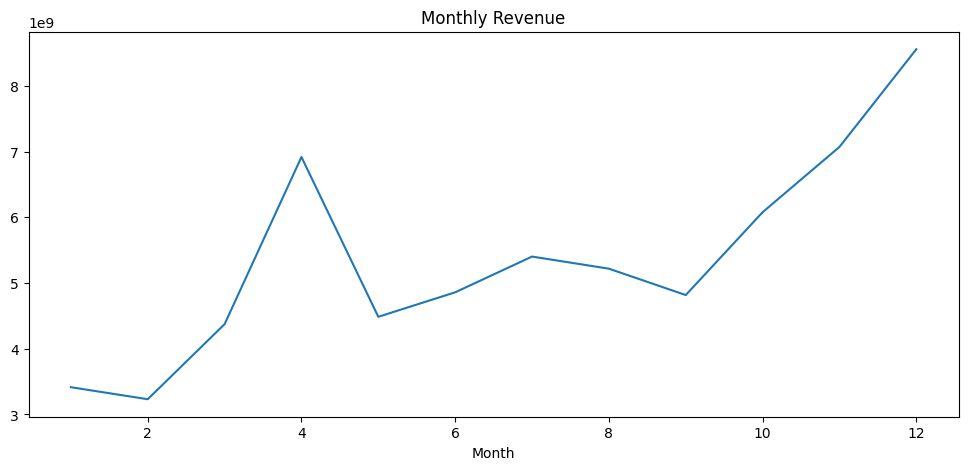

In [84]:
#Monthly Revenue
monthly_revenue = df.groupby("Month")["Revenue"].sum()

monthly_revenue.plot(kind="line", figsize=(12,5))
plt.title("Monthly Revenue")
plt.show()

In [85]:
df.to_csv("processed_billing_data.csv", index=False)

In [86]:
# ======================================
# Time Series Feature Engineering
# ======================================

In [87]:
df['Year'] = df['Billing_Date'].dt.year
df['Month'] = df['Billing_Date'].dt.month
df['Month_Name'] = df['Billing_Date'].dt.month_name()
df['Day'] = df['Billing_Date'].dt.day
df['Weekday'] = df['Billing_Date'].dt.day_name()
df['Quarter'] = df['Billing_Date'].dt.quarter

df['Is_Weekend'] = df['Weekday'].isin(['Saturday', 'Sunday'])

df.head()

,SKU,Billing_Date,Billing_Quantity,Customer_ID,Year,Month,Price,Revenue,Month_Name,Day,Weekday,Quarter,Is_Weekend
0,GC1010,2024-04-01,15,1S010933,2024,4,701,10515,April,1,Monday,2,False
1,XJ0100,2024-04-01,70,1S008042,2024,4,3928,274960,April,1,Monday,2,False
2,VL1011,2024-04-01,29,1S012273,2024,4,859,24911,April,1,Monday,2,False
3,HD0111,2024-04-01,48,1S004896,2024,4,3306,158688,April,1,Monday,2,False
4,WY1111,2024-04-01,14,1S004896,2024,4,217,3038,April,1,Monday,2,False


In [88]:
#This shows transaction activity over time.
daily_trend = df.groupby('Billing_Date')['Billing_Quantity'].sum()

print(daily_trend.head(10))

Billing_Date
2024-04-01    24772
2024-04-02    26677
2024-04-03    25882
2024-04-04    28399
2024-04-05    28165
2024-04-06    34832
2024-04-07    35122
2024-04-08    25987
2024-04-09    29047
2024-04-10    28896
Name: Billing_Quantity, dtype: int64


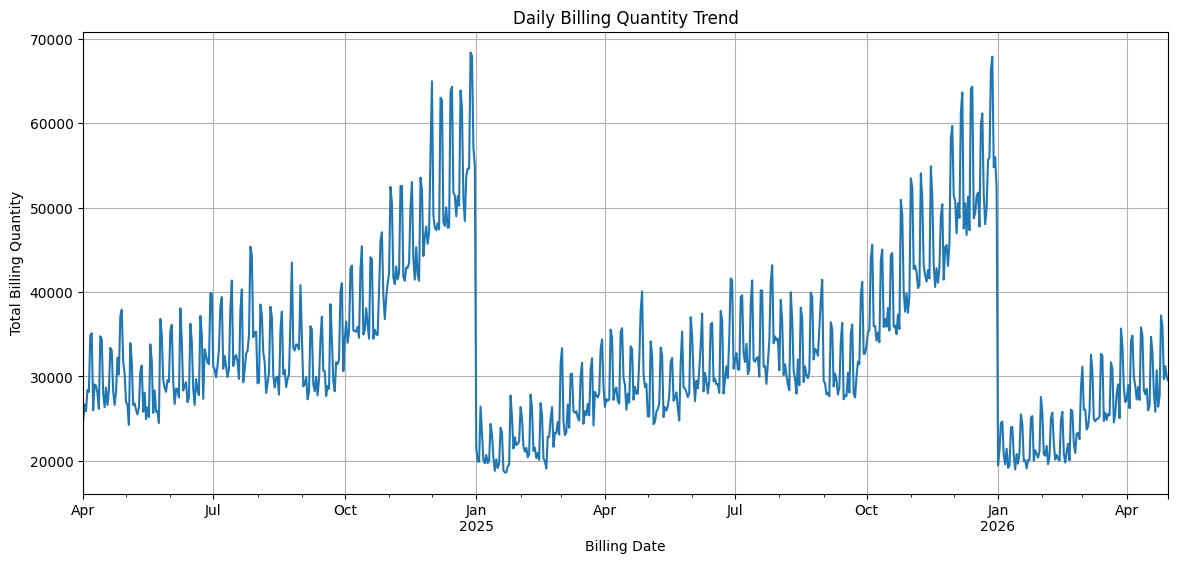

In [89]:
#Plotting daily billing trend
plt.figure(figsize=(14,6))

daily_trend.plot()

plt.title('Daily Billing Quantity Trend')
plt.xlabel('Billing Date')
plt.ylabel('Total Billing Quantity')

plt.grid(True)

plt.show()

In [90]:
#Monthly Billing Analysis
monthly_trend = df.groupby(['Month', 'Month_Name'])['Billing_Quantity'].sum()

monthly_trend = monthly_trend.sort_index()

print(monthly_trend)

Month  Month_Name
1      January       1332485
2      February      1269660
3      March         1714777
4      April         2702816
5      May           1764906
6      June          1901428
7      July          2122062
8      August        2052678
9      September     1886941
10     October       2391457
11     November      2768347
12     December      3363273
Name: Billing_Quantity, dtype: int64


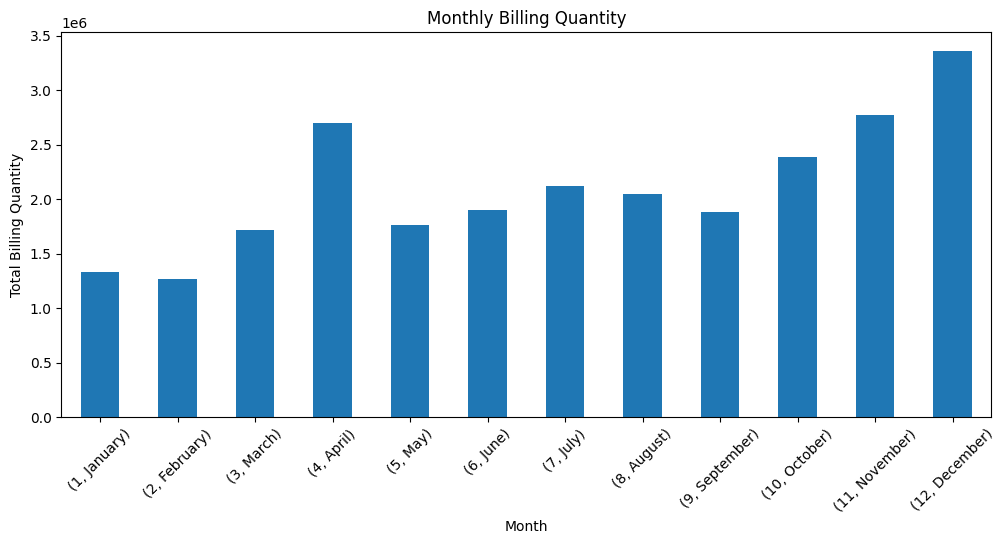

In [91]:
plt.figure(figsize=(12,5))

monthly_trend.plot(kind='bar')

plt.title('Monthly Billing Quantity')
plt.xlabel('Month')
plt.ylabel('Total Billing Quantity')

plt.xticks(rotation=45)

plt.show()

In [92]:
#Weekend vs Weekday Analysis
weekend_analysis = df.groupby('Is_Weekend')['Billing_Quantity'].sum()

print(weekend_analysis)

Is_Weekend
False    16883141
True      8387689
Name: Billing_Quantity, dtype: int64


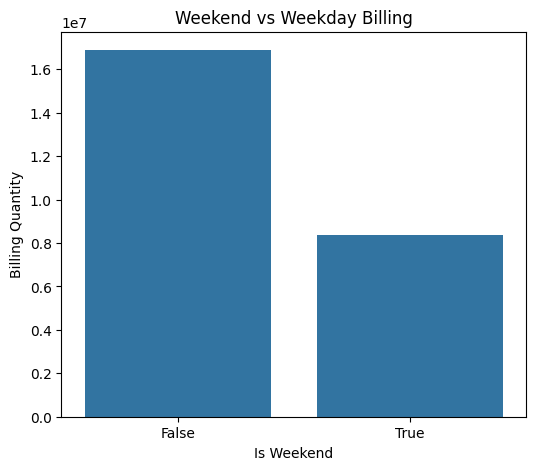

In [93]:
#Plotting Weekend Analysis
plt.figure(figsize=(6,5))

sns.barplot(
    x=weekend_analysis.index.astype(str),
    y=weekend_analysis.values
)

plt.title('Weekend vs Weekday Billing')
plt.xlabel('Is Weekend')
plt.ylabel('Billing Quantity')

plt.show()

In [94]:
#Weekday Analysis
weekday_sales = df.groupby('Weekday')['Billing_Quantity'].sum()

print(weekday_sales)

Weekday
Friday       3316509
Monday       3408726
Saturday     4193735
Sunday       4193954
Thursday     3353387
Tuesday      3410386
Wednesday    3394133
Name: Billing_Quantity, dtype: int64


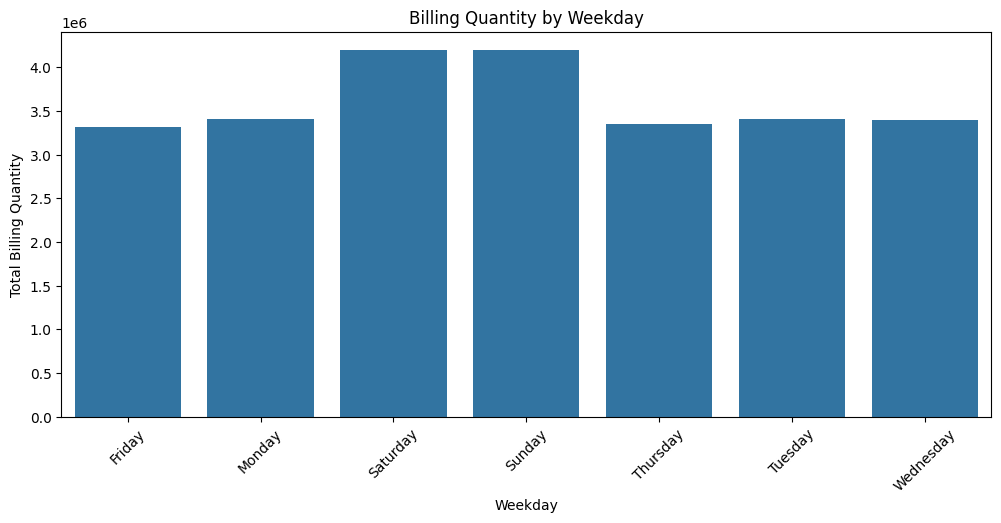

In [95]:
#Plotting Weekday Ananlysis
plt.figure(figsize=(12,5))

sns.barplot(
    x=weekday_sales.index,
    y=weekday_sales.values
)

plt.title('Billing Quantity by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Total Billing Quantity')

plt.xticks(rotation=45)

plt.show()

In [96]:
#Top 10 Billing Dates
top_dates = daily_trend.sort_values(ascending=False).head(10)

print(top_dates)

Billing_Date
2024-12-28    68361
2024-12-29    67949
2025-12-28    67870
2025-12-27    66309
2024-12-01    64956
2025-12-14    64308
2024-12-15    64299
2025-12-13    64068
2024-12-21    63857
2024-12-14    63706
Name: Billing_Quantity, dtype: int64


In [97]:
# # BUSINESS INSIGHTS:

# # 1. Billing activity increases significantly during weekends.
# # 2. Certain weekdays generate higher transaction volume.
# # 3. Some dates show abnormal spikes indicating seasonal demand.
# # 4. Monthly transaction behavior indicates changing customer activity patterns.

# This section demonstrates:

# Time-series analytics
# Feature engineering
# Groupby operations

In [98]:
# ======================================
# Customer Analytics
# ======================================

In [99]:
# Total unique customers

total_customers = df['Customer_ID'].nunique()

print("Total Unique Customers:", total_customers)

Total Unique Customers: 15000


In [100]:
#Transactions per customer of top 10 customers
customer_transactions = df.groupby('Customer_ID').size()

print(customer_transactions.head(10))

Customer_ID
1S000001    44
1S000002    20
1S000003    45
1S000004    26
1S000005    29
1S000006    23
1S000007    11
1S000008    25
1S000009    27
1S000010    61
dtype: int64


In [101]:
#Top 10 most active customers
top_customers = customer_transactions.sort_values(ascending=False).head(10)

print(top_customers)

Customer_ID
1S012841    21518
1S008333    11250
1S004896    10712
1S013320    10581
1S008042     9926
1S014615     8634
1S000781     7744
1S014564     7521
1S005569     7114
1S000209     6832
dtype: int64


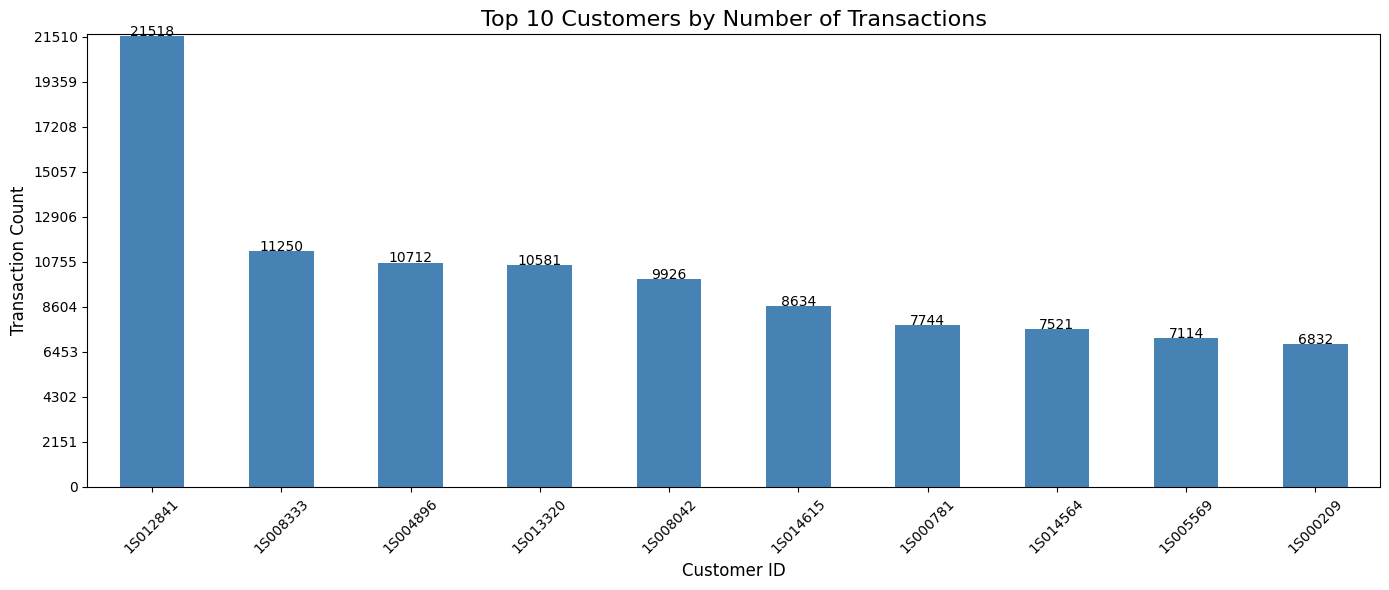

In [102]:
# Top 10 customers by transaction count
top_customers = (
    df['Customer_ID']
    .value_counts()
    .head(10)
)

# Plot
plt.figure(figsize=(14,6))

top_customers.plot(
    kind='bar',
    color='steelblue'
)

# Titles and labels
plt.title(
    'Top 10 Customers by Number of Transactions',
    fontsize=16
)

plt.xlabel(
    'Customer ID',
    fontsize=12
)

plt.ylabel(
    'Transaction Count',
    fontsize=12
)

# Dynamic Y-axis
max_value = top_customers.max()

plt.ylim(0, max_value + 100)

# Dynamic intervals
step = max(50, int(max_value / 10))

plt.yticks(
    range(0, int(max_value + 150), step)
)

# Rotate labels
plt.xticks(rotation=45)

# Add value labels on bars
for index, value in enumerate(top_customers.values):

    plt.text(
        index,
        value + 10,
        str(value),
        ha='center',
        fontsize=10
    )

plt.tight_layout()

plt.show()

In [103]:
#Total Billing quantity per customer of top 10 customers
customer_quantity = df.groupby('Customer_ID')['Billing_Quantity'].sum()

print(customer_quantity.head(10))

Customer_ID
1S000001     901
1S000002     556
1S000003    1266
1S000004     668
1S000005     894
1S000006     497
1S000007     354
1S000008     656
1S000009     689
1S000010    1533
Name: Billing_Quantity, dtype: int64


In [104]:
#Top Customers by Billing Quantity
top_quantity_customers = customer_quantity.sort_values(ascending=False).head(10)

print(top_quantity_customers)

Customer_ID
1S012841    543122
1S008333    284160
1S004896    269860
1S013320    265778
1S008042    251085
1S014615    219540
1S000781    196444
1S014564    188454
1S005569    180939
1S000209    173640
Name: Billing_Quantity, dtype: int64


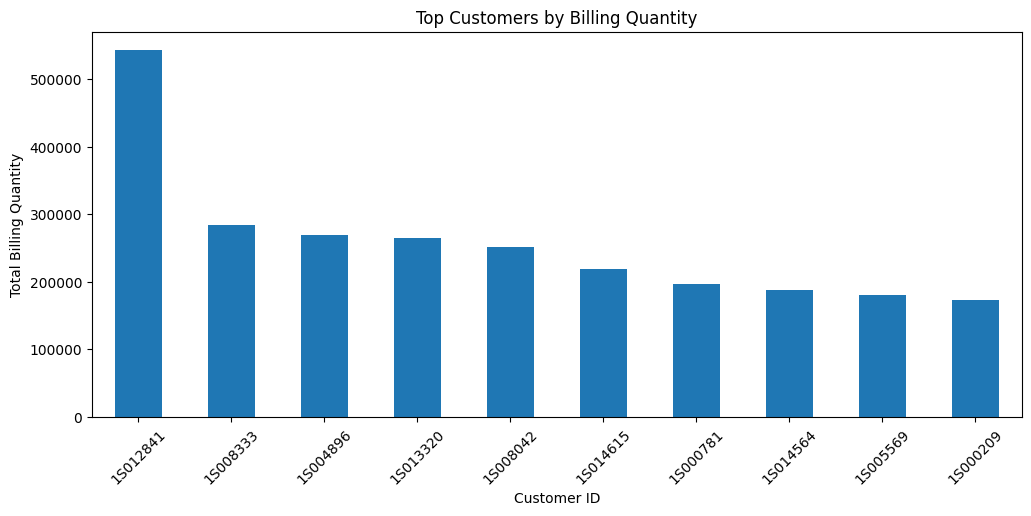

In [105]:
plt.figure(figsize=(12,5))

top_quantity_customers.plot(kind='bar')

plt.title('Top Customers by Billing Quantity')
plt.xlabel('Customer ID')
plt.ylabel('Total Billing Quantity')

plt.xticks(rotation=45)

plt.show()

In [106]:
#Repeat Customers Ananlysis
repeat_customers = customer_transactions[customer_transactions > 1]

print("Repeat Customers:", len(repeat_customers))

Repeat Customers: 15000


In [107]:
#One Time Customers
one_time_customers = customer_transactions[customer_transactions == 1]

print("One-Time Customers:", len(one_time_customers))

One-Time Customers: 0


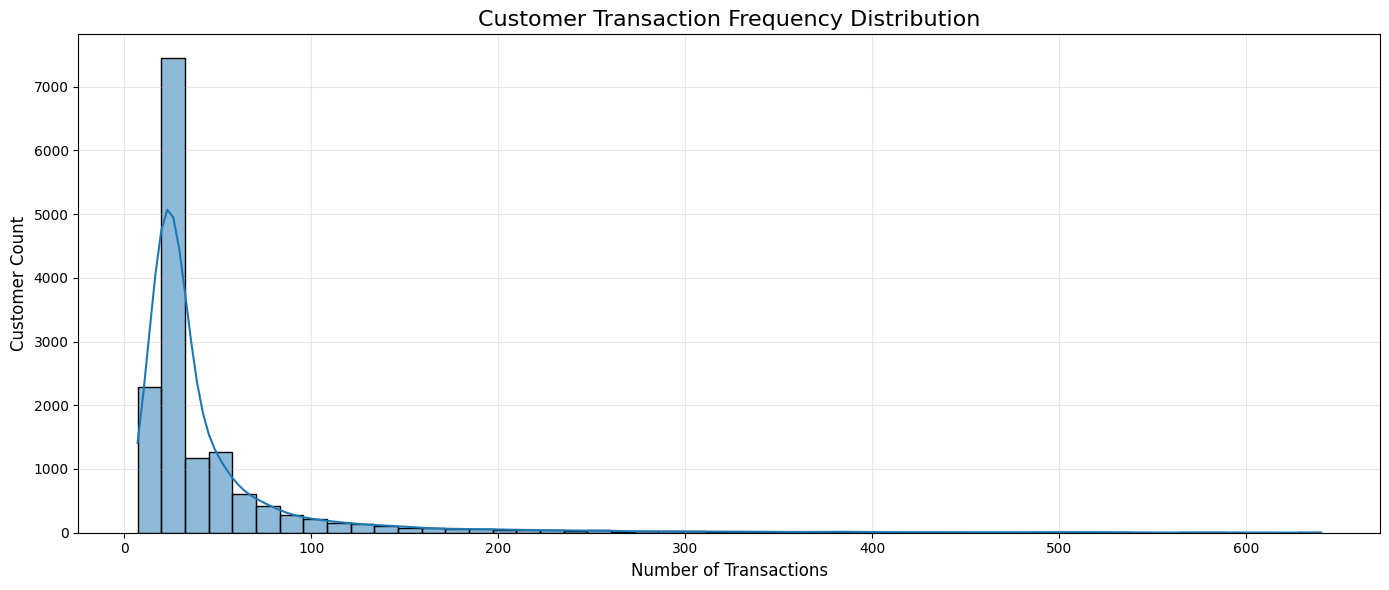

In [127]:
# ======================================
# Customer Frequency Distribution
# ======================================

plt.figure(figsize=(14,6))

# Remove extreme outliers for better visualization
filtered_transactions = customer_transactions[
    customer_transactions < customer_transactions.quantile(0.99)
]

# Histogram
sns.histplot(
    filtered_transactions,
    bins=50,
    kde=True
)

# Titles and labels
plt.title(
    'Customer Transaction Frequency Distribution',
    fontsize=16
)

plt.xlabel(
    'Number of Transactions',
    fontsize=12
)

plt.ylabel(
    'Customer Count',
    fontsize=12
)

# Grid for readability
plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [109]:
# CUSTOMER ANALYTICS INSIGHTS

# 1. A small group of customers contributes significantly to transactions.
# 2. Repeat customers indicate customer retention behavior.
# 3. Some customers generate very high billing quantities.
# 4. Transaction frequency distribution helps identify loyal customers.

In [110]:
# ======================================
# SKU/Product Analysis
# ======================================

In [111]:
#total quantity sold for each product/SKU (first 10)
sku_total = df.groupby('SKU')['Billing_Quantity'].sum()

print(sku_total.head(10))

SKU
A0000    6298
A0001    4329
A0010    3380
A0011    1389
A0100    2754
A0101    1722
A0110     151
A0111     280
A1000    2997
A1001    3156
Name: Billing_Quantity, dtype: int64


In [112]:
#highest-performing products
top_skus = sku_total.sort_values(ascending=False).head(10)

print(top_skus)

SKU
CQ1111    14291
PS1010    14167
RZ1100    13326
EP1011    12981
DB1001    12034
BT0100    11815
MB1110    11781
TX0101    11711
WJ1001    11547
OP1111    11509
Name: Billing_Quantity, dtype: int64


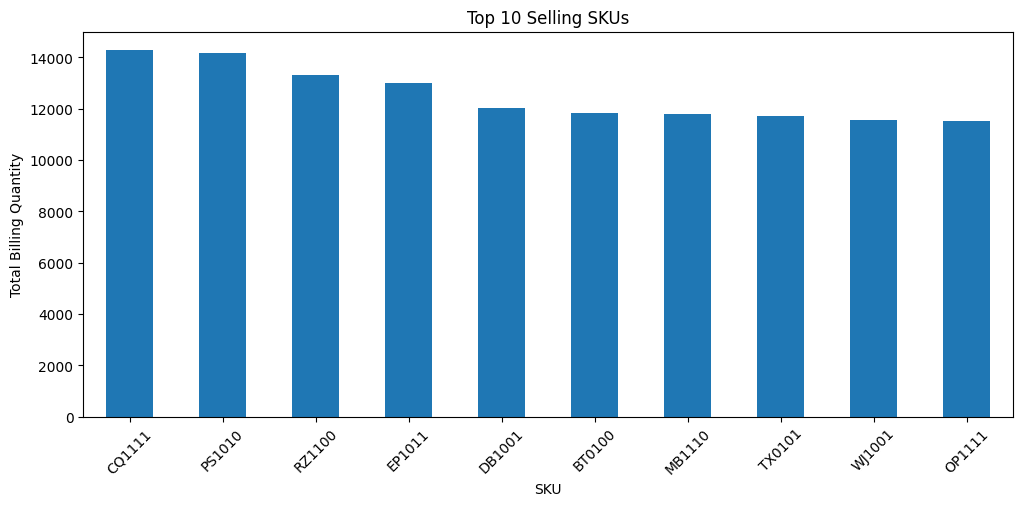

In [113]:
plt.figure(figsize=(12,5))

top_skus.plot(kind='bar')

plt.title('Top 10 Selling SKUs')
plt.xlabel('SKU')
plt.ylabel('Total Billing Quantity')

plt.xticks(rotation=45)

plt.show()

In [114]:
#Lowest performing products
least_skus = sku_total.sort_values().head(10)

print(least_skus)

SKU
NN0111    1
RU0111    1
NF1100    2
UA0011    3
XZ0101    3
HE1110    4
M1111     5
BO1110    6
DS0110    6
YD1000    7
Name: Billing_Quantity, dtype: int64


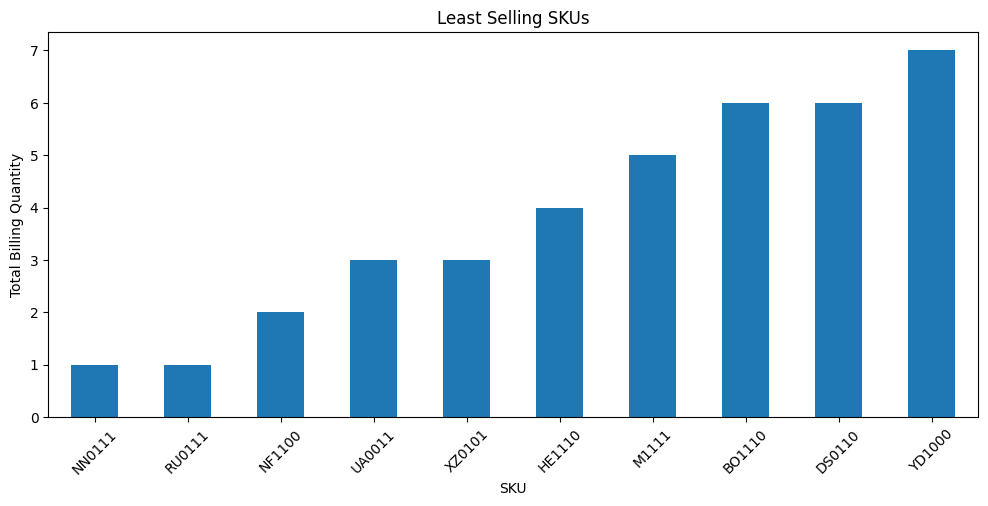

In [115]:
plt.figure(figsize=(12,5))

least_skus.plot(kind='bar')

plt.title('Least Selling SKUs')
plt.xlabel('SKU')
plt.ylabel('Total Billing Quantity')

plt.xticks(rotation=45)

plt.show()

In [116]:
#First 10 SKU Transaction Frequency
sku_frequency = df.groupby('SKU').size()

print(sku_frequency.head(10))

SKU
A0000    255
A0001    177
A0010    142
A0011     63
A0100    112
A0101     72
A0110      6
A0111     12
A1000    120
A1001    130
dtype: int64


In [117]:
#Top 10 Frequently Purchased SKUs
top_frequency_skus = sku_frequency.sort_values(ascending=False).head(10)

print(top_frequency_skus)

SKU
CQ1111    560
PS1010    557
RZ1100    520
EP1011    497
DB1001    475
BT0100    475
MB1110    458
WJ1001    455
N0110     447
OP1111    445
dtype: int64


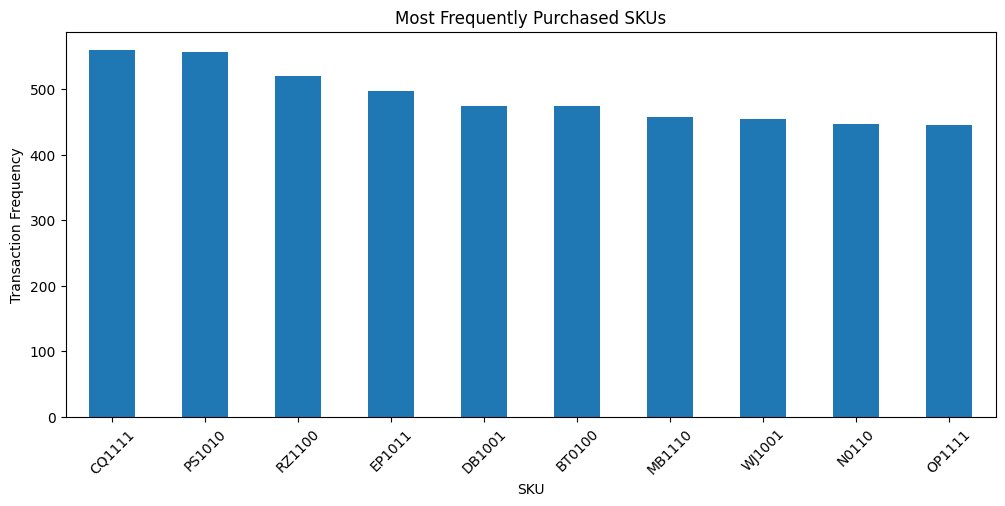

In [118]:
plt.figure(figsize=(12,5))

top_frequency_skus.plot(kind='bar')

plt.title('Most Frequently Purchased SKUs')
plt.xlabel('SKU')
plt.ylabel('Transaction Frequency')

plt.xticks(rotation=45)

plt.show()

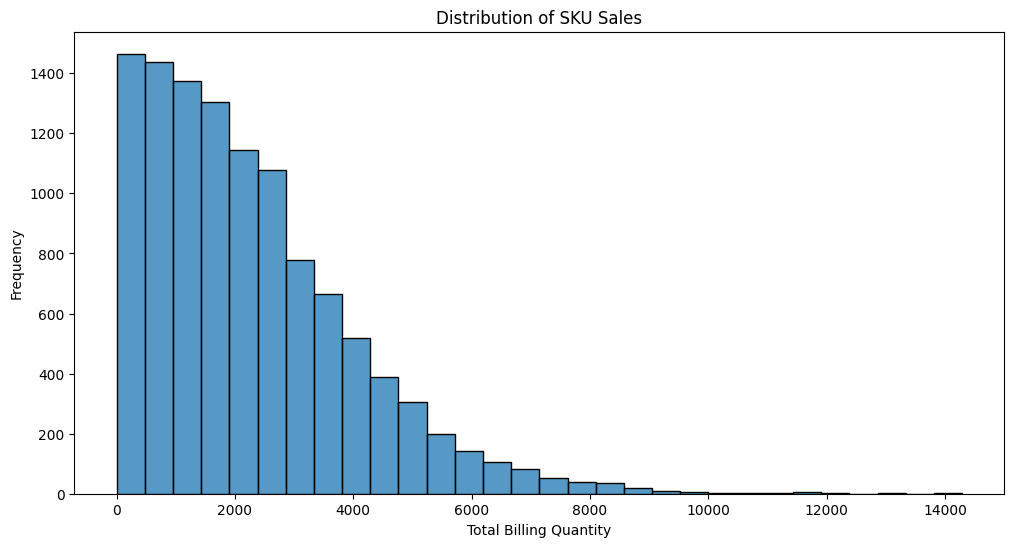

In [119]:
#SKU distribution plot
plt.figure(figsize=(12,6))

sns.histplot(sku_total, bins=30)

plt.title('Distribution of SKU Sales')
plt.xlabel('Total Billing Quantity')
plt.ylabel('Frequency')

plt.show()

In [120]:
# INSIGHTS:

# 1. Certain SKUs contribute significantly more billing quantity than others.
# 2. Some products appear frequently in transactions despite lower total quantity.
# 3. Low-performing SKUs may require promotional strategies or inventory review.
# 4. Product demand distribution appears relatively balanced across synthetic data.

# This section demonstrates:

# product analytics
# grouping & aggregation
# ranking analysis
# categorical visualization
# frequency analysis
# business intelligence interpretation

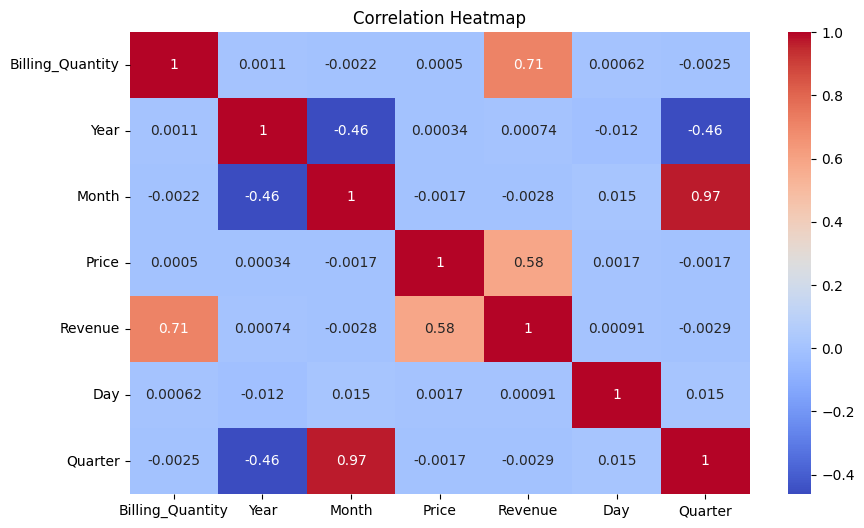

In [121]:
#Correlation Heatmap
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

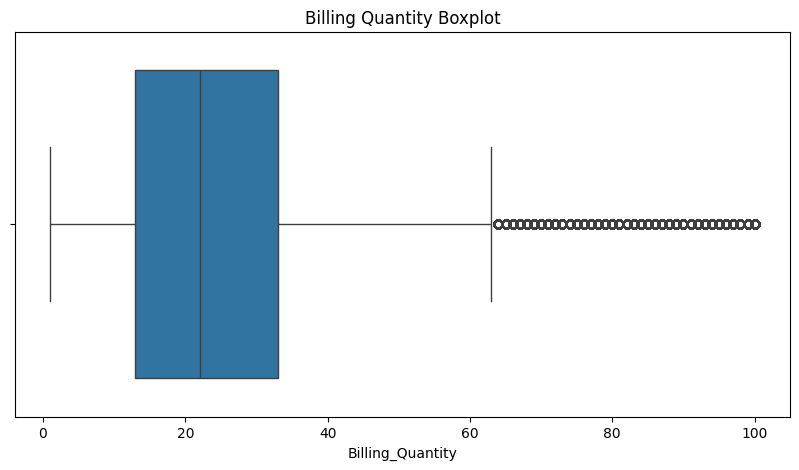

In [122]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['Billing_Quantity'])

plt.title('Billing Quantity Boxplot')

plt.show()

In [123]:
print("Mean:", df['Billing_Quantity'].mean())
print("Median:", df['Billing_Quantity'].median())
print("Mode:", df['Billing_Quantity'].mode()[0])

print("Variance:", df['Billing_Quantity'].var())
print("Standard Deviation:", df['Billing_Quantity'].std())

print("Skewness:", df['Billing_Quantity'].skew())
print("Kurtosis:", df['Billing_Quantity'].kurt())

Mean: 25.27083
Median: 22.0
Mode: 15
Variance: 289.4059685170685
Standard Deviation: 17.011936060221615
Skewness: 1.425695125848428
Kurtosis: 2.80258895435006


In [124]:
df.to_csv('processed_billing_data.csv', index=False)


RFM Table Sample:

  Customer_ID  Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score  \
0    1S000001       62         44   2337652       1       3       3       133   
1    1S000002       39         20   1316068       2       1       1       211   
2    1S000003       10         45   3574957       3       3       4       334   
3    1S000004        4         26   1897503       4       2       3       423   
4    1S000005       26         29   1869980       2       3       3       233   

               Segment  
0              At Risk  
1  Potential Loyalists  
2            Champions  
3      Loyal Customers  
4                 Lost  


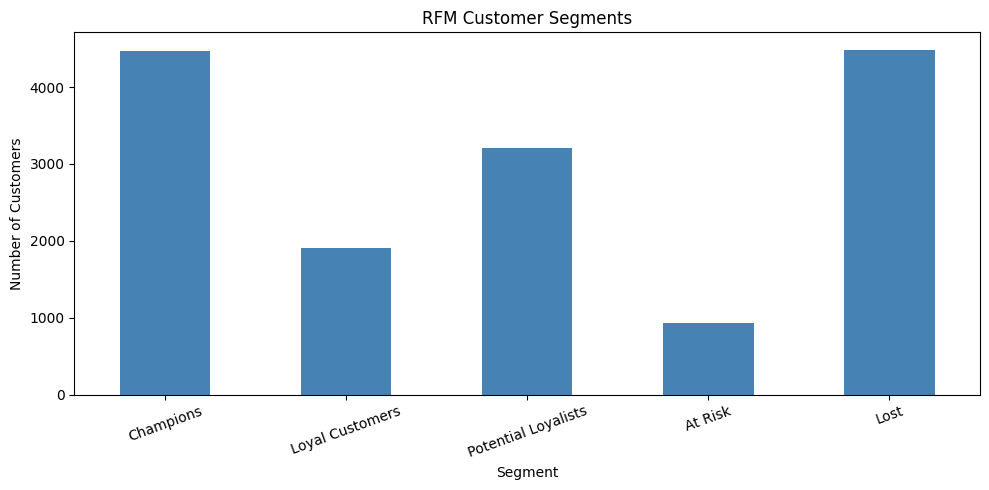


Average RFM Values by Segment:

                     Recency  Frequency     Monetary
Segment                                             
At Risk                67.66      35.90   2305382.27
Champions               6.39     161.07  10404642.53
Lost                   61.90      29.92   1932828.84
Loyal Customers         7.96      25.06   1542223.18
Potential Loyalists    20.58      20.38   1314478.26

Segment Counts:

Segment
Champions              4465
Loyal Customers        1912
Potential Loyalists    3210
At Risk                 925
Lost                   4488
Name: count, dtype: int64


In [ ]:
# ======================================
# RFM Customer Segmentation
# Classifies customers into actionable business segments
# ======================================

import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

# Create Snapshot Date
snapshot_date = df['Billing_Date'].max() + timedelta(days=1)

# Create RFM Table
rfm = df.groupby('Customer_ID').agg(
    
    # Days since last purchase
    Recency = (
        'Billing_Date',
        lambda x: (snapshot_date - x.max()).days
    ),
    
    # Number of transactions
    Frequency = (
        'Customer_ID',
        'count'
    ),
    
    # Total revenue generated
    Monetary = (
        'Revenue',
        'sum'
    )

).reset_index()

# RFM Scoring (1–4)

# Recency Score
# Lower recency = better
rfm['R_Score'] = pd.qcut(
    rfm['Recency'].rank(method='first'),
    q=4,
    labels=[4,3,2,1]
)

# Frequency Score
# Higher frequency = better
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    q=4,
    labels=[1,2,3,4]
)

# Monetary Score
# Higher monetary = better
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'].rank(method='first'),
    q=4,
    labels=[1,2,3,4]
)

# Combine Scores
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

# Customer Segmentation Function
def segment(row):

    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])

    # Best customers
    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions'

    # Frequent & recent buyers
    elif r >= 3 and f >= 2:
        return 'Loyal Customers'

    # Can become loyal later
    elif r >= 2 and f <= 2:
        return 'Potential Loyalists'

    # Previously active but inactive now
    elif r == 1 and f >= 3:
        return 'At Risk'

    # Low activity customers
    else:
        return 'Lost'

# Apply segmentation
rfm['Segment'] = rfm.apply(segment, axis=1)

# Display Sample Data
print("\nRFM Table Sample:\n")

print(rfm.head())

# Segment Distribution Plot

# Custom order for segments
segment_order = [
    'Champions',
    'Loyal Customers',
    'Potential Loyalists',
    'At Risk',
    'Lost'
]

# Count segments in desired order
segment_counts = (
    rfm['Segment']
    .value_counts()
    .reindex(segment_order)
)

# Plot graph
plt.figure(figsize=(10,5))

segment_counts.plot(
    kind='bar',
    color='steelblue'
)

plt.title('RFM Customer Segments')

plt.xlabel('Segment')

plt.ylabel('Number of Customers')

plt.xticks(rotation=20)

plt.tight_layout()

plt.show()

# Average RFM Values Per Segment
print("\nAverage RFM Values by Segment:\n")

print(
    rfm.groupby('Segment')[
        ['Recency', 'Frequency', 'Monetary']
    ]
    .mean()
    .round(2)
)

# Segment Counts
print("\nSegment Counts:\n")

print(segment_counts)

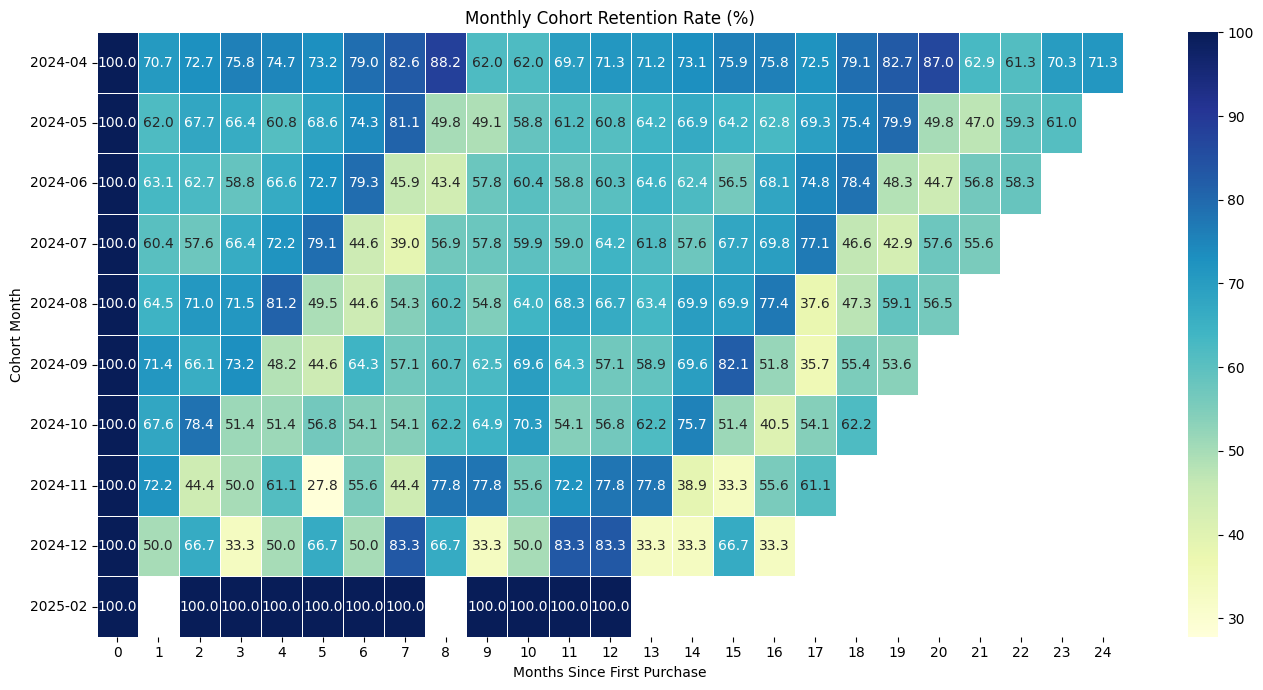

In [ ]:
# ======================================
# Cohort Retention Analysis
# Shows if customers are returning over time (loyalty)
# ======================================

df['CohortMonth'] = df.groupby('Customer_ID')['Billing_Date'].transform('min').dt.to_period('M')
df['TransactionMonth'] = df['Billing_Date'].dt.to_period('M')

cohort_data = df.groupby(['CohortMonth', 'TransactionMonth'])['Customer_ID'].nunique().reset_index()
cohort_data['PeriodNumber'] = (
    cohort_data['TransactionMonth'] - cohort_data['CohortMonth']
).apply(lambda x: x.n)

cohort_pivot = cohort_data.pivot_table(index='CohortMonth', columns='PeriodNumber', values='Customer_ID')

# Retention rate
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0).round(3) * 100

plt.figure(figsize=(14, 7))
sns.heatmap(retention, annot=True, fmt='.1f', cmap='YlGnBu', linewidths=0.5)
plt.title('Monthly Cohort Retention Rate (%)')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.show()

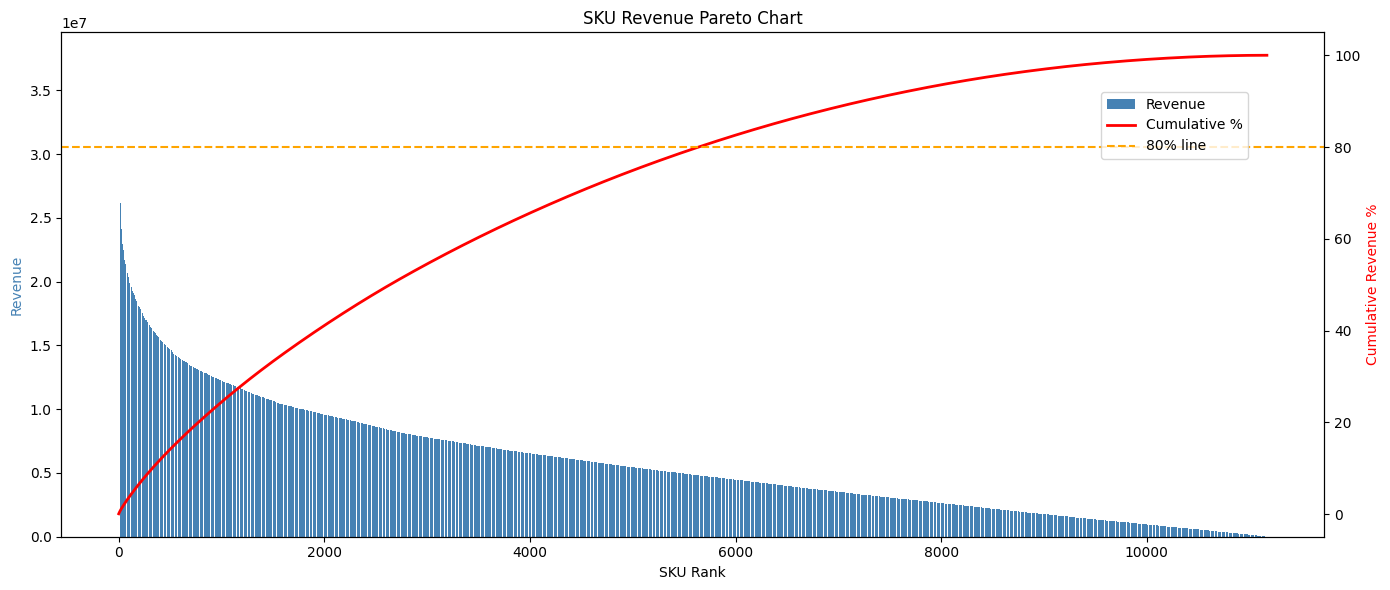

Top 5640 SKUs out of 11168 contribute 80% of revenue


In [ ]:
# ======================================
# Pareto Analysis — SKU Revenue
# Identifies which few SKUs/customers drive most revenue
# ======================================

sku_revenue = df.groupby('SKU')['Revenue'].sum().sort_values(ascending=False).reset_index()
sku_revenue['Cumulative_%'] = sku_revenue['Revenue'].cumsum() / sku_revenue['Revenue'].sum() * 100
sku_revenue['SKU_Rank'] = range(1, len(sku_revenue)+1)

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.bar(sku_revenue['SKU_Rank'], sku_revenue['Revenue'], color='steelblue', label='Revenue')
ax1.set_xlabel('SKU Rank')
ax1.set_ylabel('Revenue', color='steelblue')

ax2 = ax1.twinx()
ax2.plot(sku_revenue['SKU_Rank'], sku_revenue['Cumulative_%'], color='red', linewidth=2, label='Cumulative %')
ax2.axhline(80, color='orange', linestyle='--', label='80% line')
ax2.set_ylabel('Cumulative Revenue %', color='red')

plt.title('SKU Revenue Pareto Chart')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.85))
plt.tight_layout()
plt.show()

cutoff = sku_revenue[sku_revenue['Cumulative_%'] <= 80].shape[0]
print(f"Top {cutoff} SKUs out of {len(sku_revenue)} contribute 80% of revenue")

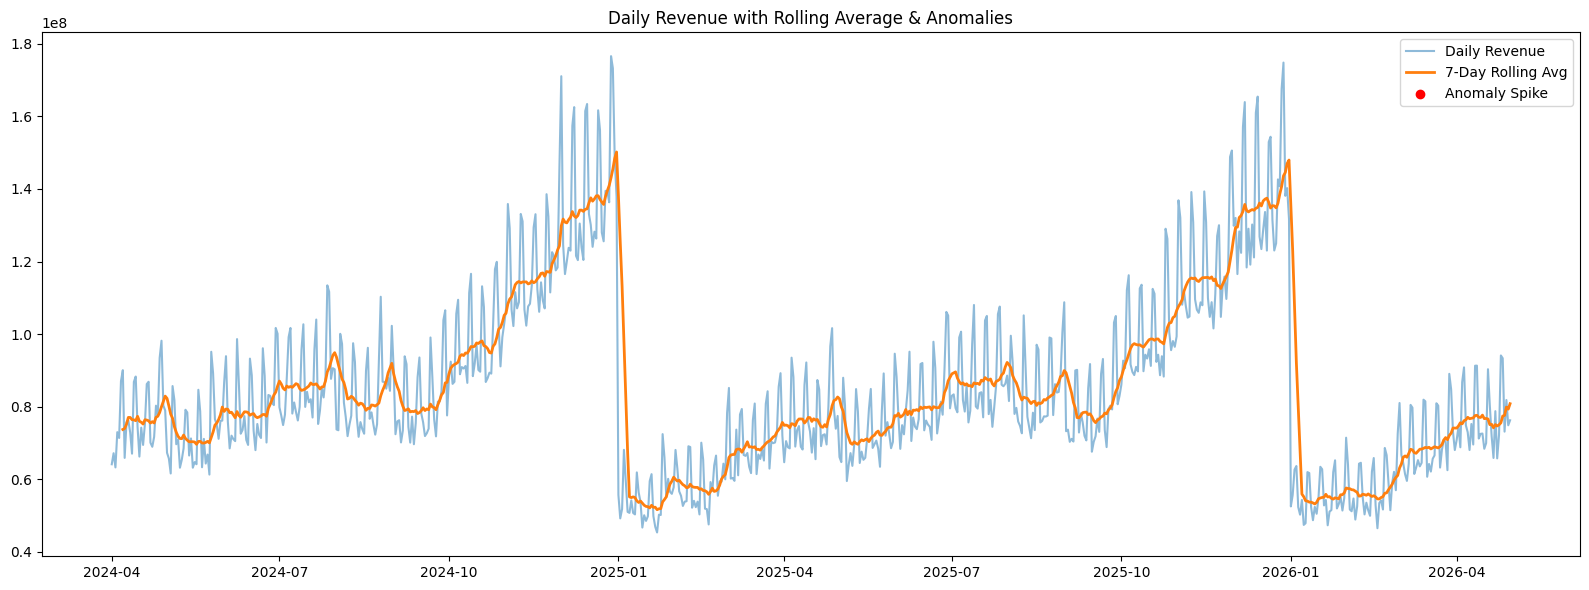

In [ ]:
# ======================================
# 7-Day Rolling Revenue + Anomaly Flags
# Flags unusual revenue spikes automatically
# ======================================

daily_revenue = df.groupby('Billing_Date')['Revenue'].sum().reset_index().set_index('Billing_Date')

daily_revenue['7D_Rolling_Avg'] = daily_revenue['Revenue'].rolling(7).mean()
daily_revenue['7D_Rolling_Std'] = daily_revenue['Revenue'].rolling(7).std()

# Flag days more than 2 std deviations above rolling mean
daily_revenue['Anomaly'] = daily_revenue['Revenue'] > (
    daily_revenue['7D_Rolling_Avg'] + 2 * daily_revenue['7D_Rolling_Std']
)

plt.figure(figsize=(16, 6))
plt.plot(daily_revenue.index, daily_revenue['Revenue'], label='Daily Revenue', alpha=0.5)
plt.plot(daily_revenue.index, daily_revenue['7D_Rolling_Avg'], label='7-Day Rolling Avg', linewidth=2)
plt.scatter(
    daily_revenue[daily_revenue['Anomaly']].index,
    daily_revenue[daily_revenue['Anomaly']]['Revenue'],
    color='red', zorder=5, label='Anomaly Spike'
)
plt.title('Daily Revenue with Rolling Average & Anomalies')
plt.legend()
plt.tight_layout()
plt.show()

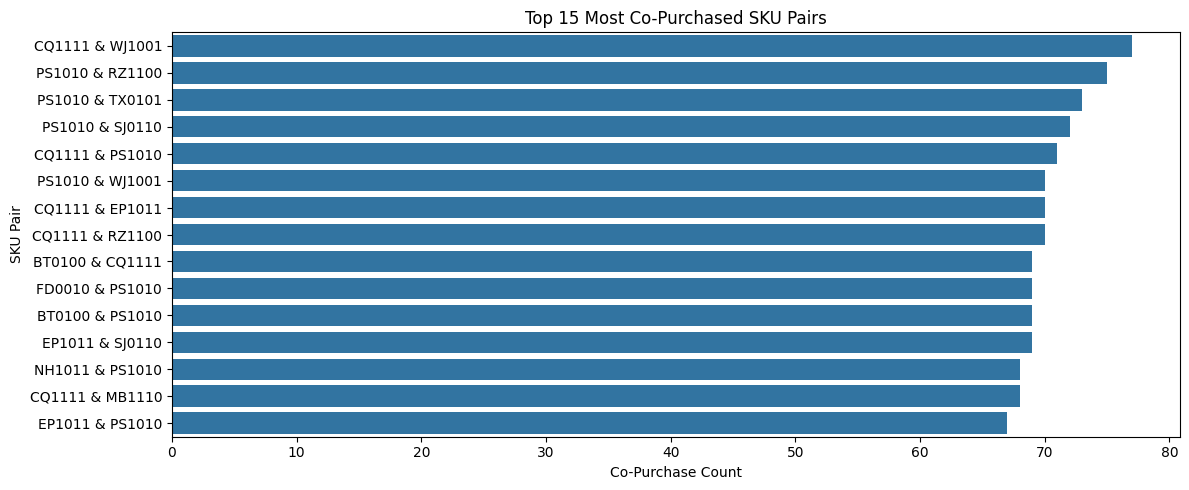

In [ ]:
# ======================================
# Market Basket — Most Co-Purchased SKU Pairs
# Finds which products are bought together (cross-sell signals)
# ======================================
from itertools import combinations
from collections import Counter

basket = df.groupby('Customer_ID')['SKU'].apply(list)

pair_counts = Counter()
for items in basket:
    unique_items = list(set(items))
    for pair in combinations(sorted(unique_items), 2):
        pair_counts[pair] += 1

top_pairs = pd.DataFrame(pair_counts.most_common(15), columns=['SKU_Pair', 'Co_Purchase_Count'])
top_pairs['SKU_A'] = top_pairs['SKU_Pair'].apply(lambda x: x[0])
top_pairs['SKU_B'] = top_pairs['SKU_Pair'].apply(lambda x: x[1])

plt.figure(figsize=(12, 5))
sns.barplot(data=top_pairs, x='Co_Purchase_Count', y=top_pairs['SKU_A'] + ' & ' + top_pairs['SKU_B'])
plt.title('Top 15 Most Co-Purchased SKU Pairs')
plt.xlabel('Co-Purchase Count')
plt.ylabel('SKU Pair')
plt.tight_layout()
plt.show()

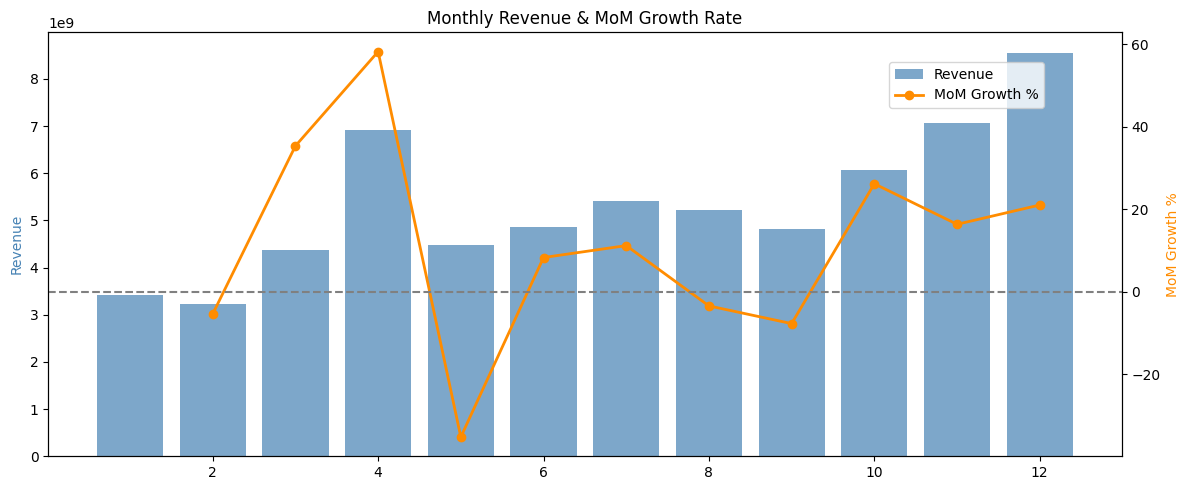

In [ ]:
# ======================================
# Month-over-Month Revenue Growth
# Reveals acceleration/deceleration in revenue trends
# ======================================

monthly_rev = df.groupby('Month')['Revenue'].sum().reset_index()
monthly_rev['MoM_Growth_%'] = monthly_rev['Revenue'].pct_change() * 100

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(monthly_rev['Month'], monthly_rev['Revenue'], color='steelblue', alpha=0.7, label='Revenue')
ax1.set_ylabel('Revenue', color='steelblue')

ax2 = ax1.twinx()
ax2.plot(monthly_rev['Month'], monthly_rev['MoM_Growth_%'], color='darkorange', marker='o', linewidth=2, label='MoM Growth %')
ax2.axhline(0, color='gray', linestyle='--')
ax2.set_ylabel('MoM Growth %', color='darkorange')

plt.title('Monthly Revenue & MoM Growth Rate')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.show()

Churn_Label
Medium    13951
High       1041
Low           8
Name: count, dtype: int64


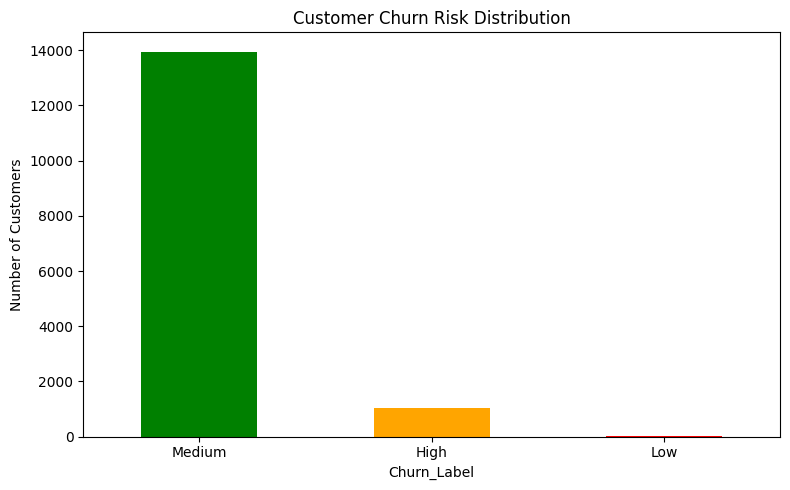

In [ ]:
# ======================================
# Churn Risk Scoring
# Which customers are about to leave
# ======================================

snapshot = df['Billing_Date'].max()

churn_df = df.groupby('Customer_ID').agg(
    Last_Purchase = ('Billing_Date', 'max'),
    Frequency     = ('Customer_ID', 'count'),
    Total_Revenue = ('Revenue', 'sum')
).reset_index()

churn_df['Days_Since_Purchase'] = (snapshot - churn_df['Last_Purchase']).dt.days

# Normalize each factor to 0–1 score
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

churn_df['Recency_Score']   = 1 - scaler.fit_transform(churn_df[['Days_Since_Purchase']])  # higher days = higher churn risk
churn_df['Frequency_Score'] = scaler.fit_transform(churn_df[['Frequency']])
churn_df['Monetary_Score']  = scaler.fit_transform(churn_df[['Total_Revenue']])

# Weighted churn risk (higher = more likely to churn)
churn_df['Churn_Risk'] = (
    0.5 * (1 - churn_df['Recency_Score']) +
    0.3 * (1 - churn_df['Frequency_Score']) +
    0.2 * (1 - churn_df['Monetary_Score'])
)

churn_df['Churn_Label'] = pd.cut(churn_df['Churn_Risk'], bins=[0,0.33,0.66,1.0], labels=['Low','Medium','High'])

print(churn_df['Churn_Label'].value_counts())

plt.figure(figsize=(8,5))
churn_df['Churn_Label'].value_counts().plot(kind='bar', color=['green','orange','red'])
plt.title('Customer Churn Risk Distribution')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

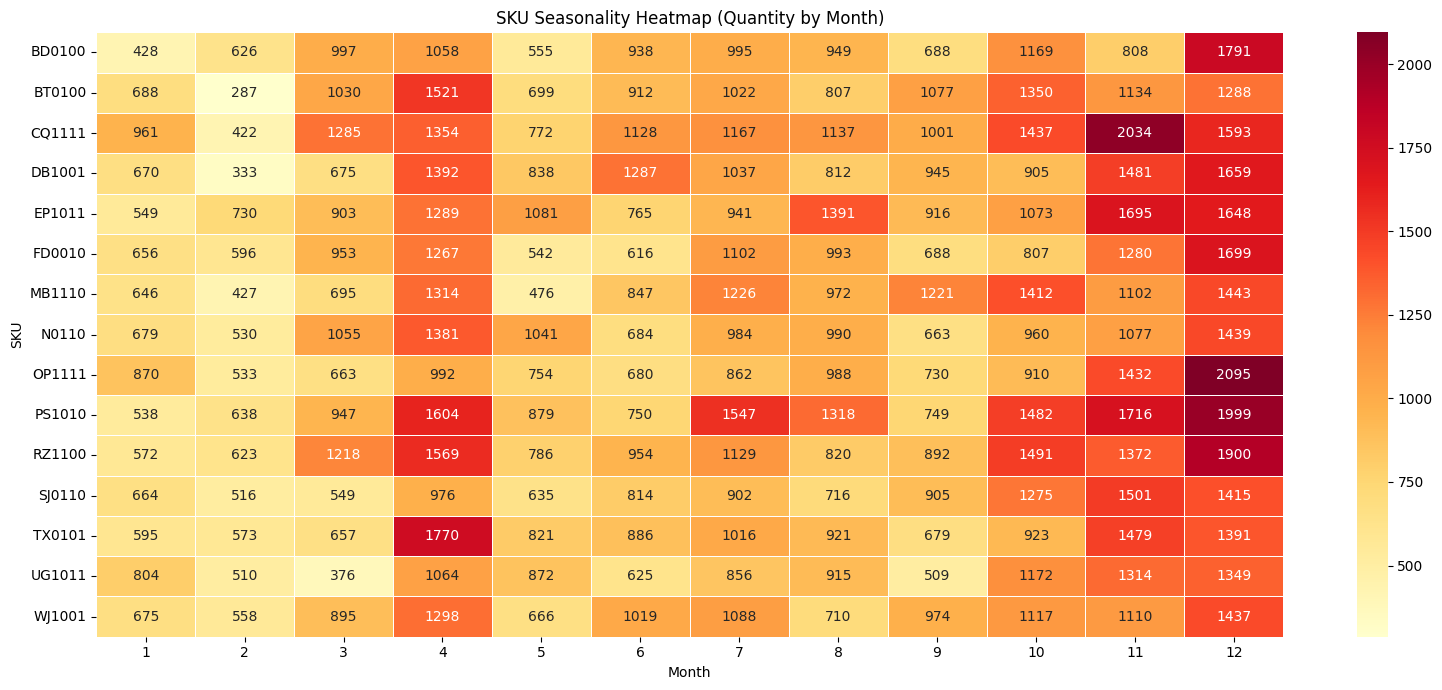

In [ ]:
# ======================================
# SKU Seasonality — Top 15 SKUs by Month
# Which products peak in which months
# ======================================

top15_skus = df['SKU'].value_counts().head(15).index

seasonal = df[df['SKU'].isin(top15_skus)].groupby(['Month','SKU'])['Billing_Quantity'].sum().unstack(fill_value=0)

plt.figure(figsize=(16, 7))
sns.heatmap(seasonal.T, cmap='YlOrRd', annot=True, fmt='d', linewidths=0.5)
plt.title('SKU Seasonality Heatmap (Quantity by Month)')
plt.xlabel('Month')
plt.ylabel('SKU')
plt.tight_layout()
plt.show()

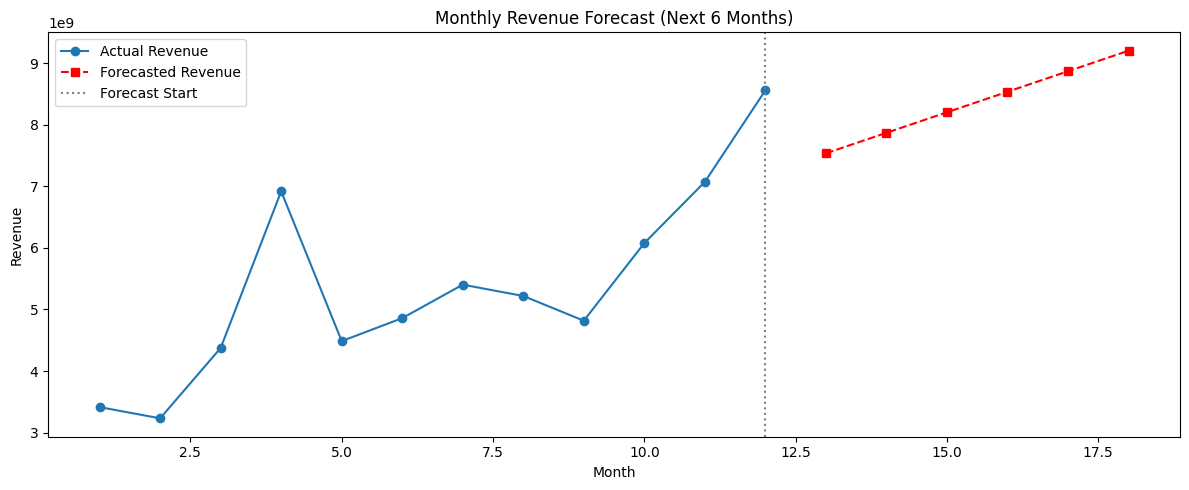

 Month  Predicted_Revenue
    13       7.535169e+09
    14       7.868376e+09
    15       8.201582e+09
    16       8.534788e+09
    17       8.867994e+09
    18       9.201200e+09


In [135]:
# ======================================
# Revenue Forecasting — Linear Regression
# ======================================
from sklearn.linear_model import LinearRegression

monthly_rev = df.groupby('Month')['Revenue'].sum().reset_index()
monthly_rev.columns = ['Month', 'Revenue']

X = monthly_rev[['Month']]
y = monthly_rev['Revenue']

model = LinearRegression()
model.fit(X, y)

# Forecast next 6 months
future_months = pd.DataFrame({'Month': range(monthly_rev['Month'].max()+1,
                                              monthly_rev['Month'].max()+7)})
future_months['Predicted_Revenue'] = model.predict(future_months)

plt.figure(figsize=(12, 5))
plt.plot(monthly_rev['Month'], monthly_rev['Revenue'], marker='o', label='Actual Revenue')
plt.plot(future_months['Month'], future_months['Predicted_Revenue'],
         marker='s', linestyle='--', color='red', label='Forecasted Revenue')
plt.axvline(monthly_rev['Month'].max(), color='gray', linestyle=':', label='Forecast Start')
plt.title('Monthly Revenue Forecast (Next 6 Months)')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.legend()
plt.tight_layout()
plt.show()

print(future_months.to_string(index=False))

Avg days between purchases: 10.7
Median days between purchases: 2.0


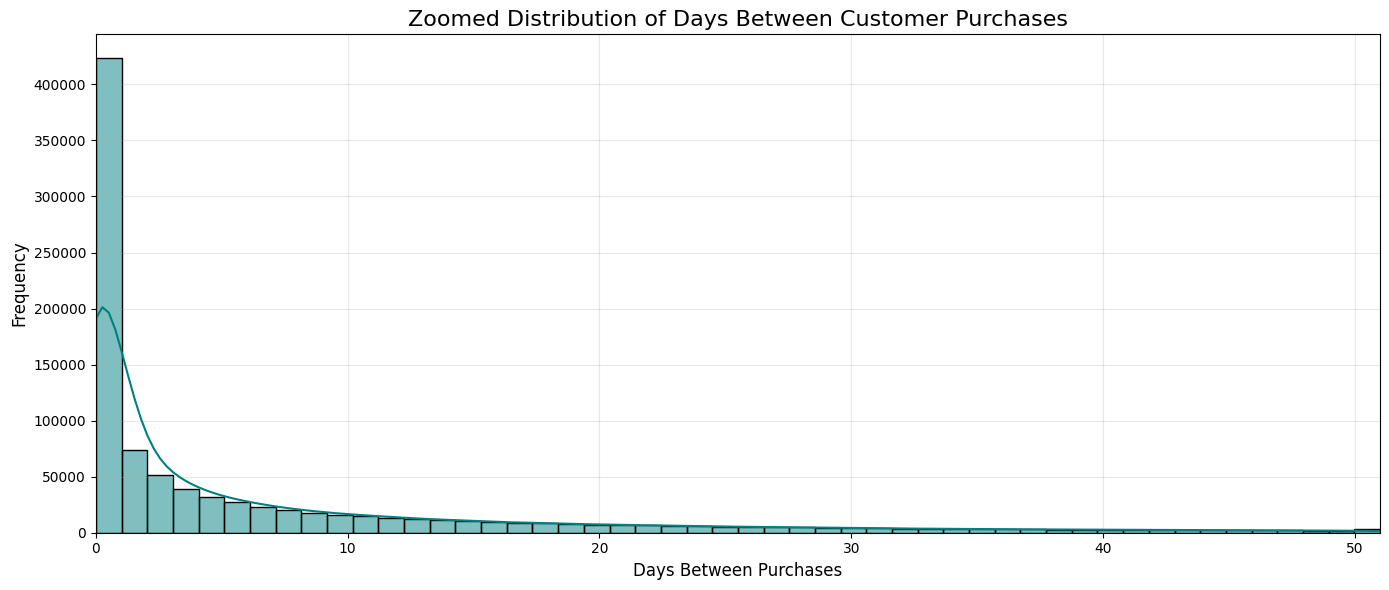


Top 10 customers with longest average gap (lapsing risk):
Customer_ID
1S007890    112.166667
1S008170     86.625000
1S010820     83.375000
1S001100     80.111111
1S000459     80.000000
1S006776     78.555556
1S010361     76.555556
1S002311     76.000000
1S002715     75.333333
1S007135     74.555556
Name: Days_Between, dtype: float64


In [140]:
# ======================================
# Inter-Purchase Time Analysis
# ZOOMED VERSION
# ======================================

# Sort data customer-wise
df_sorted = df.sort_values(
    ['Customer_ID', 'Billing_Date']
)

# Previous purchase date
df_sorted['Prev_Purchase'] = (
    df_sorted.groupby('Customer_ID')['Billing_Date']
    .shift(1)
)

# Days between purchases
df_sorted['Days_Between'] = (
    df_sorted['Billing_Date']
    - df_sorted['Prev_Purchase']
).dt.days

# Remove null values
gap_stats = df_sorted.dropna(
    subset=['Days_Between']
)

# --------------------------------------
# Summary Statistics
# --------------------------------------

print(
    "Avg days between purchases:",
    round(gap_stats['Days_Between'].mean(), 1)
)

print(
    "Median days between purchases:",
    gap_stats['Days_Between'].median()
)

# --------------------------------------
# ZOOMED GRAPH
# --------------------------------------

# Remove extreme outliers for visualization
zoomed_gaps = gap_stats[
    gap_stats['Days_Between']
    <= gap_stats['Days_Between'].quantile(0.95)
]

# Plot
plt.figure(figsize=(14,6))

sns.histplot(
    zoomed_gaps['Days_Between'],
    bins=50,
    kde=True,
    color='teal'
)

# Titles
plt.title(
    'Zoomed Distribution of Days Between Customer Purchases',
    fontsize=16
)

plt.xlabel(
    'Days Between Purchases',
    fontsize=12
)

plt.ylabel(
    'Frequency',
    fontsize=12
)

# Zoom x-axis
plt.xlim(
    0,
    zoomed_gaps['Days_Between'].max()
)

# Grid
plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# --------------------------------------
# High Gap Customers
# --------------------------------------

avg_gap = (
    gap_stats.groupby('Customer_ID')['Days_Between']
    .mean()
    .sort_values(ascending=False)
)

print(
    "\nTop 10 customers with longest average gap (lapsing risk):"
)

print(avg_gap.head(10))

ABC_Class
A    4450
C    3939
B    2779
Name: count, dtype: int64

Revenue by Class:
ABC_Class
A    45100456634
B    12886683889
C     6444808737
Name: Revenue, dtype: int64


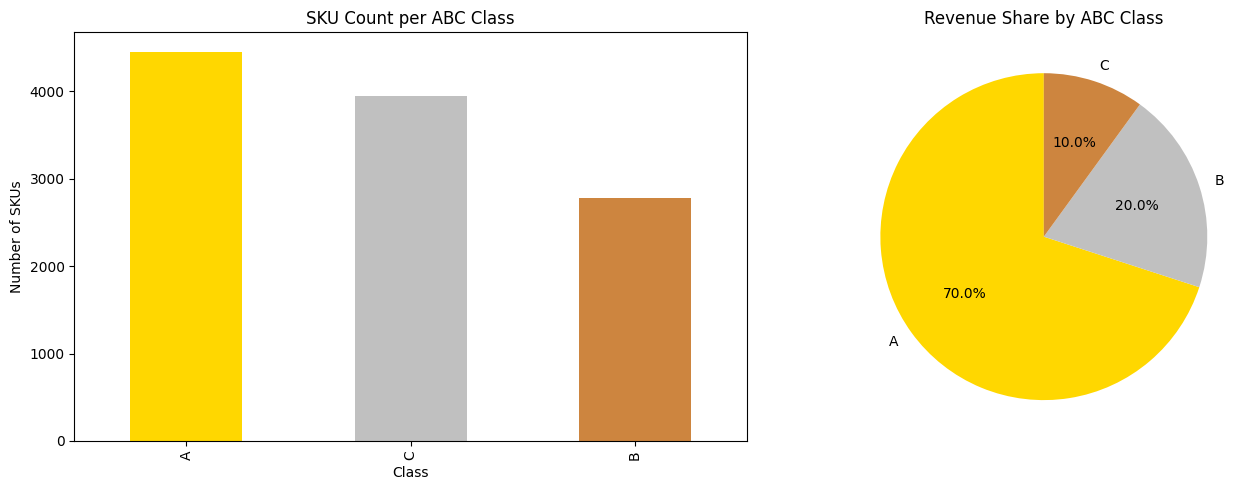

In [137]:
# ======================================
# ABC Inventory Classification
# ======================================

sku_rev = df.groupby('SKU')['Revenue'].sum().sort_values(ascending=False).reset_index()
sku_rev['Cumulative_%'] = sku_rev['Revenue'].cumsum() / sku_rev['Revenue'].sum() * 100

# A = top 0–70%, B = 70–90%, C = 90–100%
def abc_class(cum_pct):
    if cum_pct <= 70:  return 'A'
    elif cum_pct <= 90: return 'B'
    else:               return 'C'

sku_rev['ABC_Class'] = sku_rev['Cumulative_%'].apply(abc_class)

print(sku_rev['ABC_Class'].value_counts())
print("\nRevenue by Class:")
print(sku_rev.groupby('ABC_Class')['Revenue'].sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sku_rev['ABC_Class'].value_counts().plot(kind='bar', ax=axes[0], color=['gold','silver','peru'])
axes[0].set_title('SKU Count per ABC Class')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of SKUs')

sku_rev.groupby('ABC_Class')['Revenue'].sum().plot(kind='pie', ax=axes[1],
    autopct='%1.1f%%', colors=['gold','silver','peru'], startangle=90)
axes[1].set_title('Revenue Share by ABC Class')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

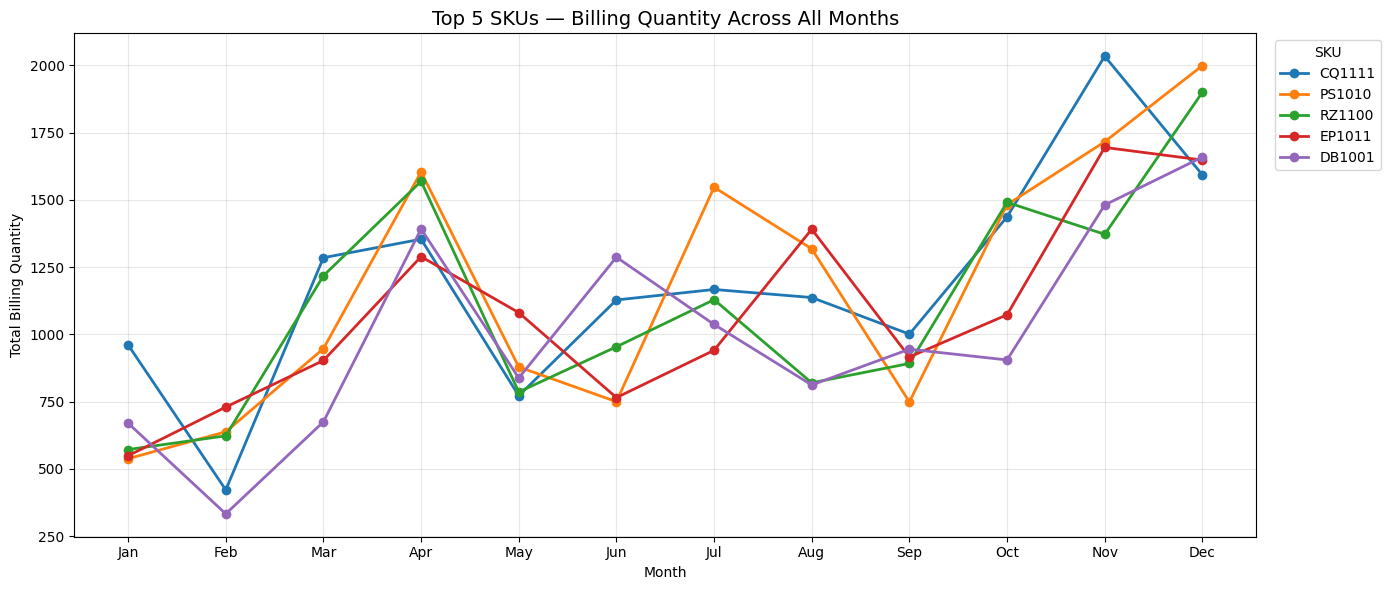

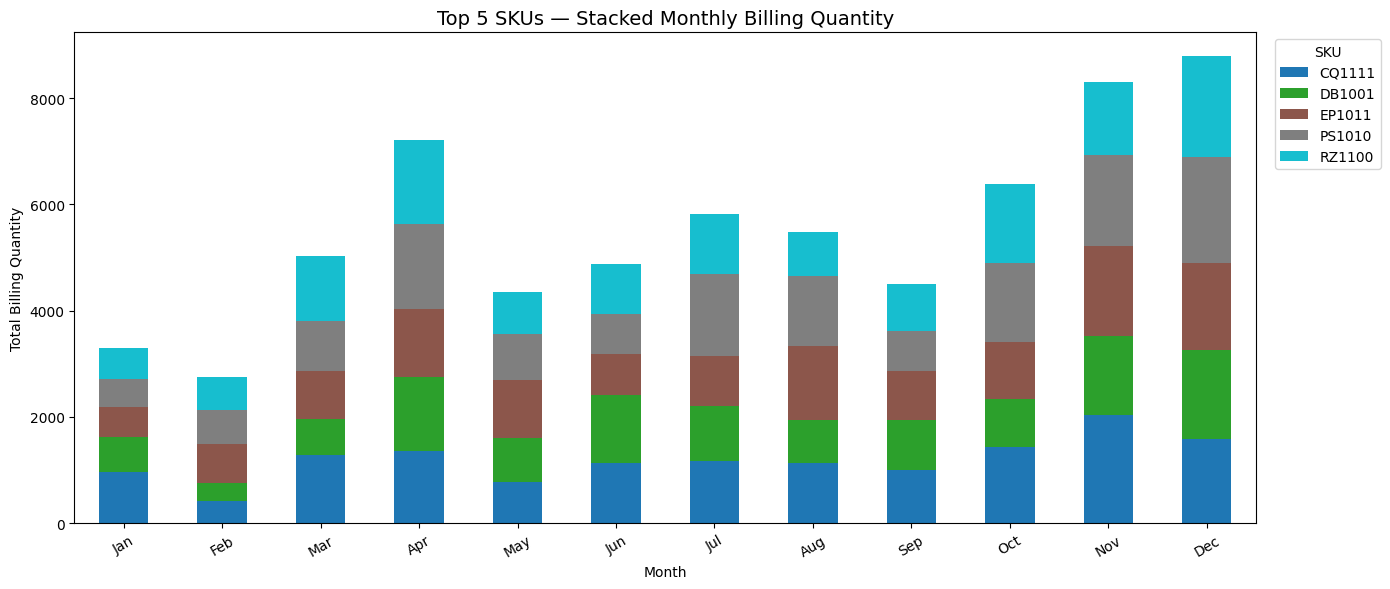

In [144]:
# ======================================
# Top 5 SKUs Performance Across All Months
# ======================================

# Get top 5 SKUs by total billing quantity
top5_skus = df.groupby('SKU')['Billing_Quantity'].sum().sort_values(ascending=False).head(5).index

# Filter data for top 5 SKUs
top5_df = df[df['SKU'].isin(top5_skus)]

# Group by Month + SKU
monthly_sku = top5_df.groupby(['Month', 'SKU'])['Billing_Quantity'].sum().reset_index()

# Plot
plt.figure(figsize=(14, 6))

for sku in top5_skus:
    sku_data = monthly_sku[monthly_sku['SKU'] == sku]
    plt.plot(sku_data['Month'], sku_data['Billing_Quantity'], marker='o', linewidth=2, label=sku)

plt.title('Top 5 SKUs — Billing Quantity Across All Months', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Billing Quantity')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.legend(title='SKU', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
# Pivot for stacked bar
pivot = monthly_sku.pivot(index='Month', columns='SKU', values='Billing_Quantity').fillna(0)

pivot.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='tab10')

plt.title('Top 5 SKUs — Stacked Monthly Billing Quantity', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Billing Quantity')
plt.xticks(ticks=range(12),
           labels=['Jan','Feb','Mar','Apr','May','Jun',
                   'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=30)
plt.legend(title='SKU', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()